In [62]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import Counter, defaultdict
import itertools
import ast
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [53]:

folder_path = Path(r"C:\Users\ydmar\Documents\UW\Master thesis\Master_thesis\ai_specialties\output")

rows = []

for file_path in sorted(folder_path.glob("*.txt")):
    try:
        with file_path.open("r", encoding="utf-8") as f:
            text = f.read()
        
        text_clean = re.sub(r"\s+", " ", text.lower()).strip()
        
        rows.append({
            "file_name": file_path.name,
            "file_stem": file_path.stem,   
            "file_path": str(file_path),
            "text": text,
            "text_clean": text_clean,
            "n_characters": len(text),
            "n_words": len(text_clean.split())
        })
    
    except Exception as e:
        print(f"Error reading {file_path.name}: {e}")

df_files = pd.DataFrame(rows)

print(df_files.head())
print(f"\nLoaded {len(df_files)} files.")

     file_name file_stem                                          file_path  \
0    anx_I.txt     anx_I  C:\Users\ydmar\Documents\UW\Master thesis\Mast...   
1   anx_II.txt    anx_II  C:\Users\ydmar\Documents\UW\Master thesis\Mast...   
2  anx_III.txt   anx_III  C:\Users\ydmar\Documents\UW\Master thesis\Mast...   
3   anx_IV.txt    anx_IV  C:\Users\ydmar\Documents\UW\Master thesis\Mast...   
4   anx_IX.txt    anx_IX  C:\Users\ydmar\Documents\UW\Master thesis\Mast...   

                                                text  \
0  ANNEX I\nList of Union harmonisation legislati...   
1  ANNEX II\nList of criminal offences referred t...   
2  ANNEX III\nHigh-risk AI systems referred to in...   
3  ANNEX IV\nTechnical documentation referred to ...   
4  ANNEX IX\nInformation to be submitted upon the...   

                                          text_clean  n_characters  n_words  
0  annex i list of union harmonisation legislatio...          5880      958  
1  annex ii list of criminal off

In [54]:
labour_terms = {
    'employment':   r'\bemploy(ment|er|ee|ed|ing|s)\b',
    'ICT':          r'\b(ICT|information\s+and\s+communication\s+technology)\b',
    'worker':       r'\bworker(s)?\b',
    'job':          r'\bjob(s)?\b',
    'wage':         r'\bwage(s)?\b',
    'salary':       r'\bsalary(s)?\b',
    'training':     r'\btrain(ing|ed)?\b',
    'skill':        r'\bskill(s|ed)?\b',
    'education':    r'\beducat(ion|ional|e)?\b',
    'self-employment': r'\bself[\s-]employ(ment|ed)?\b',
    'working conditions': r'\bwork(ing)?\s+condition(s)?\b',
}

def count_terms(text, term_dict):
    return {term: len(re.findall(pattern, text)) for term, pattern in term_dict.items()}

ranking_rows = []

for _, row in df_files.iterrows():
    counts = count_terms(row['text_clean'], labour_terms)
    total = sum(counts.values())
    density = round(total / row['n_words'] * 1000, 2) if row['n_words'] > 0 else 0
    top_terms = ', '.join([k for k, v in sorted(counts.items(), key=lambda x: -x[1])[:3] if v > 0])
    
    ranking_rows.append({
        'file_name': row['file_name'],
        'file_stem': row['file_stem'],
        'n_words': row['n_words'],
        'labour_mentions': total,
        'density_per_1k': density,
        'top_terms': top_terms,
        **{f'term_{k}': v for k, v in counts.items()}
    })

df_ranking = pd.DataFrame(ranking_rows).sort_values('density_per_1k', ascending=False).reset_index(drop=True)
df_ranking['rank'] = df_ranking.index + 1

print("=== ALL FILES RANKED BY LABOUR-MARKET RELEVANCE ===")
print(df_ranking[['rank', 'file_name', 'n_words', 'labour_mentions', 'density_per_1k', 'top_terms']].head(10).to_string(index=False))

=== ALL FILES RANKED BY LABOUR-MARKET RELEVANCE ===
 rank    file_name  n_words  labour_mentions  density_per_1k                              top_terms
    1   rct_56.txt      217               14           64.52             education, training, skill
    2   rct_57.txt      181                5           27.62    employment, worker, self-employment
    3    art_4.txt       81                2           24.69                    training, education
    4  rct_108.txt       83                2           24.10                               training
    5  rct_107.txt      171                4           23.39                               training
    6   rct_92.txt      130                3           23.08                                 worker
    7 anx_XIII.txt      242                5           20.66                               training
    8    rct_2.txt       51                1           19.61                             employment
    9    rct_9.txt      470                9    

In [55]:
# Confirm terms actually appear in the Act at all
print("=== TERM COVERAGE CHECK ===")
for term, pattern in labour_terms.items():
    n = len(re.findall(pattern, full_act_text))
    coverage = "OK" if n > 0 else "NOT FOUND"
    print(f"{term:30s}: {n:4d} mentions  {coverage}")

=== TERM COVERAGE CHECK ===
employment                    :   18 mentions  OK
ICT                           :    0 mentions  NOT FOUND
worker                        :   37 mentions  OK
job                           :    2 mentions  OK
wage                          :    0 mentions  NOT FOUND
salary                        :    0 mentions  NOT FOUND
training                      :  241 mentions  OK
skill                         :    9 mentions  OK
education                     :   42 mentions  OK
self-employment               :    3 mentions  OK
working conditions            :    8 mentions  OK


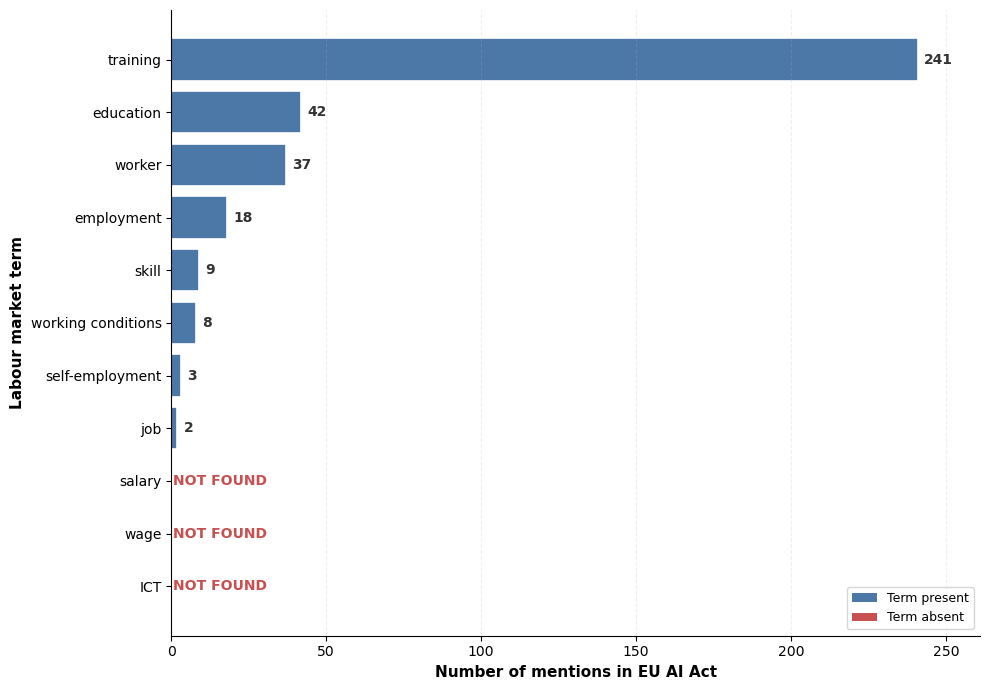


=== SUMMARY STATISTICS ===
Total terms checked:        11
Terms present in Act:       8
Terms NOT in Act:           3
Total mentions (all terms): 360

Most frequent term:         'training' (241 mentions)
Terms with 0 mentions:      ICT, wage, salary


In [75]:
# Prepare data
terms = list(labour_terms.keys())
counts = []
for term, pattern in labour_terms.items():
    n = len(re.findall(pattern, full_act_text))
    counts.append(n)

# Create dataframe for easier handling
term_data = pd.DataFrame({
    'term': terms,
    'count': counts,
    'present': ['Yes' if c > 0 else 'No' for c in counts]
})

# Sort by count descending
term_data = term_data.sort_values('count', ascending=True)

# Color coding
colors = ['#c85050' if c == 0 else '#4C78A8' for c in term_data['count']]

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    term_data['term'],
    term_data['count'],
    color=colors,
    edgecolor='white',
    linewidth=1.2
)

# Add value labels
for bar, val in zip(bars, term_data['count']):
    label = f'{val}' if val > 0 else 'NOT FOUND'
    x_pos = bar.get_width() + 2 if val > 0 else 0.5
    color = '#333333' if val > 0 else '#c85050'
    weight = 'bold' if val > 0 else 'bold'
    
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        label,
        va='center',
        ha='left',
        fontsize=10,
        color=color,
        fontweight=weight
    )

# Styling
ax.set_xlabel("Number of mentions in EU AI Act", fontsize=11, fontweight='bold')
ax.set_ylabel("Labour market term", fontsize=11, fontweight='bold')
# ax.set_title("Labour Market Term Coverage in EU AI Act\n(Regulation 2024/1689)", 
#              fontsize=12, fontweight='bold', pad=15)

max_count = term_data['count'].max()
ax.set_xlim(0, max_count + 20)

ax.grid(axis='x', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C78A8', label='Term present'),
    Patch(facecolor='#c85050', label='Term absent')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, 
          edgecolor='#cccccc', fontsize=9)

plt.tight_layout()
plt.savefig('labour_terms_coverage.png', dpi=300, bbox_inches='tight')
plt.show()

# Also print summary statistics
print("\n=== SUMMARY STATISTICS ===")
print(f"Total terms checked:        {len(term_data)}")
print(f"Terms present in Act:       {(term_data['count'] > 0).sum()}")
print(f"Terms NOT in Act:           {(term_data['count'] == 0).sum()}")
print(f"Total mentions (all terms): {term_data['count'].sum()}")
print(f"\nMost frequent term:         '{term_data.iloc[-1]['term']}' ({term_data.iloc[-1]['count']} mentions)")
print(f"Terms with 0 mentions:      {', '.join(term_data[term_data['count'] == 0]['term'].tolist())}")

A text-mining analysis of the EU AI Act (Regulation 2024/1689) reveals a structural misalignment between the regulatory framework and the empirical determinants of AI-induced wage harm. The Act contains no references to wages or salaries (0 mentions), and while employment-related AI is classified as high-risk (18 employment mentions, Annex III), this classification triggers transparency and conformity assessment obligations rather than any mechanism conditioning deployment on sectoral human capital readiness. Critically, ICT capacity — identified in our panel models as the key moderator between AI-induced displacement and wage reinstatement — appears nowhere in the Act as a deployment condition or risk-mitigation requirement. The regulatory gap is therefore not merely one of coverage, but of theoretical framing: the Act treats AI deployment risk as a procedural and transparency problem, while the empirical evidence suggests it is fundamentally a complementary-investment problem.

In [ ]:
# # Select top 5 for deep analysis
# top_files = df_ranking.head(5)['file_name'].tolist()
# print(f"\nTop 5 files selected for deep analysis: {top_files}")


Top 5 files selected for deep analysis: ['rct_56.txt', 'rct_57.txt', 'art_4.txt', 'rct_108.txt', 'rct_107.txt']


In [57]:
# Split text into sentences, keep only those with BOTH:
# (a) an obligation keyword AND (b) a labour term
# https://eur-lex.europa.eu/content/techleg/KB0213228ENN.pdf

obligation_markers = r'\b(shall|must|required to|obligation to|shall not|must not|prohibited)\b'
# Classify obligation direction
obligation_marker_classify = r'\b(shall not|must not|prohibited|shall|must|required to|obligation to)\b'

def extract_obligation_sentences(text, labour_patterns, obligation_pattern):
    sentences = re.split(r'(?<=[.;])\s+', text)
    results = []
    for sent in sentences:
        has_obligation = bool(re.search(obligation_pattern, sent))
        matched_terms = [term for term, pattern in labour_patterns.items() if re.search(pattern, sent)]
        if has_obligation and matched_terms:
            results.append({
                'sentence': sent.strip(),
                'obligation_type': re.findall(obligation_marker_classify, sent),
                'labour_terms_found': matched_terms
            })
    return results

In [58]:
obligation_rows = []

df_top = df_files[df_files['file_name'].isin(top_files)]

for _, row in df_top.iterrows():
    sentences = extract_obligation_sentences(row['text_clean'], labour_terms, obligation_markers)
    for s in sentences:
        obligation_rows.append({
            'file_name': row['file_name'],
            'sentence': s['sentence'],
            'obligation_keywords': s['obligation_type'],
            'labour_terms': s['labour_terms_found']
        })


In [59]:
df_obligations = pd.DataFrame(obligation_rows)

print(f"\n=== OBLIGATION SENTENCES (top 5 files) ===")
print(f"Total obligation-labour sentences found: {len(df_obligations)}")
print(df_obligations[['file_name', 'obligation_keywords', 'labour_terms', 'sentence']].head(10).to_string(index=False))


=== OBLIGATION SENTENCES (top 5 files) ===
Total obligation-labour sentences found: 2
 file_name obligation_keywords          labour_terms                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              sentence
 art_4.txt             [shall] [training, education]                                                                                  

In [60]:
full_text = " ".join(df_files['text_clean'].tolist())

# Extract full sentences containing 'training'
sentences_with_training = [
    s.strip() for s in re.split(r'(?<=[.;])\s+', full_text)
    if re.search(r'\btrain(ing|ed)?\b', s)
]

print(f"Total sentences with 'training': {len(sentences_with_training)}\n")
print(sentences_with_training)

Total sentences with 'training': 201

['education and vocational training: (a) ai systems intended to be used to determine access or admission or to assign natural persons to educational and vocational training institutions at all levels;', '(b) ai systems intended to be used to evaluate learning outcomes, including when those outcomes are used to steer the learning process of natural persons in educational and vocational training institutions at all levels;', '(c) ai systems intended to be used for the purpose of assessing the appropriate level of education that an individual will receive or will be able to access, in the context of or within educational and vocational training institutions at all levels;', '(d) ai systems intended to be used for monitoring and detecting prohibited behaviour of students during tests in the context of or within educational and vocational training institutions at all levels.', 'a detailed description of the elements of the ai system and of the process f

In [ ]:
df_sent = pd.DataFrame({
    "sentence_id": range(1, len(sentences_with_training) + 1),
    "sentence": sentences_with_training
})

df_sent["sentence"] = (
    df_sent["sentence"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print(df_sent.head())
print(f"Total sentences: {len(df_sent)}")

   sentence_id                                           sentence
0            1  education and vocational training: (a) ai syst...
1            2  (b) ai systems intended to be used to evaluate...
2            3  (c) ai systems intended to be used for the pur...
3            4  (d) ai systems intended to be used for monitor...
4            5  a detailed description of the elements of the ...
Total sentences: 201


In [61]:
df_sent_unique = df_sent.drop_duplicates(subset="sentence").reset_index(drop=True)

print("Original:", len(df_sent))
print("Unique:", len(df_sent_unique))
print(df_sent_unique.head())

Original: 201
Unique: 86
   sentence_id                                           sentence
0            1  education and vocational training: (a) ai syst...
1            2  (b) ai systems intended to be used to evaluate...
2            3  (c) ai systems intended to be used for the pur...
3            4  (d) ai systems intended to be used for monitor...
4            5  a detailed description of the elements of the ...


In [63]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X = vectorizer.fit_transform(df_sent_unique["sentence"])
feature_names = vectorizer.get_feature_names_out()

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (86, 544)


In [64]:
results = []

for k in range(4, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    results.append({"k": k, "silhouette": score})

df_k = pd.DataFrame(results)
print(df_k)

best_k = df_k.loc[df_k["silhouette"].idxmax(), "k"]
print("Best k by silhouette:", best_k)

   k  silhouette
0  4    0.039933
1  5    0.035564
2  6    0.037976
3  7    0.036982
4  8    0.048322
Best k by silhouette: 8


In [65]:
kmeans = KMeans(n_clusters=int(best_k), random_state=42, n_init=20)
df_sent_unique["cluster"] = kmeans.fit_predict(X)

print(df_sent_unique["cluster"].value_counts().sort_index())

cluster
0    10
1    20
2    10
3     8
4     8
5     6
6    17
7     7
Name: count, dtype: int64


In [66]:
def top_terms_per_cluster(model, feature_names, n_terms=12):
    centers = model.cluster_centers_
    cluster_terms = {}
    for i in range(centers.shape[0]):
        top_idx = centers[i].argsort()[::-1][:n_terms]
        cluster_terms[i] = [feature_names[j] for j in top_idx]
    return cluster_terms

cluster_terms = top_terms_per_cluster(kmeans, feature_names, n_terms=12)

for cl, terms in cluster_terms.items():
    print(f"\nCLUSTER {cl}")
    print(", ".join(terms))


CLUSTER 0
necessary, measures, foreseeable, human, additional, additional training, necessary competence, competence, authority, training authority, oversight, human oversight

CLUSTER 1
data, testing, ai, validation, training, training testing, testing validation, quality, high quality, quality data, systems, public

CLUSTER 2
model, including, computational, resources used, computational resources, ai, provider, resources, train, used, parties, training model

CLUSTER 3
general purpose, purpose ai, general, purpose, content used, summary content, content, summary, copyright, ai, ai models, used training

CLUSTER 4
persons, systems, vocational training, vocational, ai systems, educational, education, ai, educational vocational, institutions, levels, training institutions

CLUSTER 5
point, point operations, floating point, floating, operations, computation used, computation, training, model, time, measured, measured floating

CLUSTER 6
data, data sets, sets, validation testing, traini

In [67]:
distances = kmeans.transform(X)

for cl in sorted(df_sent_unique["cluster"].unique()):
    print("\n" + "="*80)
    print(f"CLUSTER {cl}")
    print("Top terms:", ", ".join(cluster_terms[cl]))
    
    tmp = df_sent_unique[df_sent_unique["cluster"] == cl].copy()
    tmp["distance_to_center"] = distances[tmp.index, cl]
    tmp = tmp.sort_values("distance_to_center").head(5)
    
    print("\nRepresentative sentences:")
    for _, row in tmp.iterrows():
        print(f"- {row['sentence'][:400]}")


CLUSTER 0
Top terms: necessary, measures, foreseeable, human, additional, additional training, necessary competence, competence, authority, training authority, oversight, human oversight

Representative sentences:
- deployers shall assign human oversight to natural persons who have the necessary competence, training and authority, as well as the necessary support.
- in particular, where appropriate, such measures should guarantee that the system is subject to in-built operational constraints that cannot be overridden by the system itself and is responsive to the human operator, and that the natural persons to whom human oversight has been assigned have the necessary competence, training and authority to carry out that role.
- for high-risk ai systems referred to in point 1(a) of annex iii, the measures referred to in paragraph 3 of this article shall be such as to ensure that, in addition, no action or decision is taken by the deployer on the basis of the identification resulting from

In [68]:
print(cluster_terms)

{0: ['necessary', 'measures', 'foreseeable', 'human', 'additional', 'additional training', 'necessary competence', 'competence', 'authority', 'training authority', 'oversight', 'human oversight'], 1: ['data', 'testing', 'ai', 'validation', 'training', 'training testing', 'testing validation', 'quality', 'high quality', 'quality data', 'systems', 'public'], 2: ['model', 'including', 'computational', 'resources used', 'computational resources', 'ai', 'provider', 'resources', 'train', 'used', 'parties', 'training model'], 3: ['general purpose', 'purpose ai', 'general', 'purpose', 'content used', 'summary content', 'content', 'summary', 'copyright', 'ai', 'ai models', 'used training'], 4: ['persons', 'systems', 'vocational training', 'vocational', 'ai systems', 'educational', 'education', 'ai', 'educational vocational', 'institutions', 'levels', 'training institutions'], 5: ['point', 'point operations', 'floating point', 'floating', 'operations', 'computation used', 'computation', 'trainin

In [69]:
cluster_label_map = {
    0: "Human capacity (deployer competence & oversight)",
    1: "AI model training (technical)",
    2: "AI model training (technical)",
    3: "AI model training (technical)",
    4: "AI model training (technical)",   
    5: "AI model training (technical)",
    6: "AI model training (technical)",
    7: "AI model training (technical)",
}

df_sent_unique["cluster_label"] = df_sent_unique["cluster"].map(cluster_label_map)

# Summary
summary = (
    df_sent_unique.drop_duplicates(subset="sentence")
    .groupby("cluster_label")
    .size()
    .reset_index(name="n_sentences")
)
summary["share_pct"] = (summary["n_sentences"] / summary["n_sentences"].sum() * 100).round(1)

print(summary)
print(df_sent_unique[["sentence_id", "cluster", "cluster_label"]].head(20))

                                      cluster_label  n_sentences  share_pct
0                     AI model training (technical)           76       88.4
1  Human capacity (deployer competence & oversight)           10       11.6
    sentence_id  cluster                                     cluster_label
0             1        4                     AI model training (technical)
1             2        4                     AI model training (technical)
2             3        4                     AI model training (technical)
3             4        4                     AI model training (technical)
4             5        2                     AI model training (technical)
5             6        2                     AI model training (technical)
6             7        6                     AI model training (technical)
7             8        6                     AI model training (technical)
8             9        0  Human capacity (deployer competence & oversight)
9            10       

In [70]:
df_unique_sent_2 = df_sent_unique.drop_duplicates(subset="sentence").copy()

cluster_summary = (
    df_unique_sent_2.groupby(["cluster", "cluster_label"])
    .size()
    .reset_index(name="n_sentences")
    .sort_values("n_sentences", ascending=False)
)

cluster_summary["share_pct"] = (
    cluster_summary["n_sentences"] / cluster_summary["n_sentences"].sum() * 100
).round(1)

print(cluster_summary)

   cluster                                     cluster_label  n_sentences  \
1        1                     AI model training (technical)           20   
6        6                     AI model training (technical)           17   
0        0  Human capacity (deployer competence & oversight)           10   
2        2                     AI model training (technical)           10   
3        3                     AI model training (technical)            8   
4        4                     AI model training (technical)            8   
7        7                     AI model training (technical)            7   
5        5                     AI model training (technical)            6   

   share_pct  
1       23.3  
6       19.8  
0       11.6  
2       11.6  
3        9.3  
4        9.3  
7        8.1  
5        7.0  


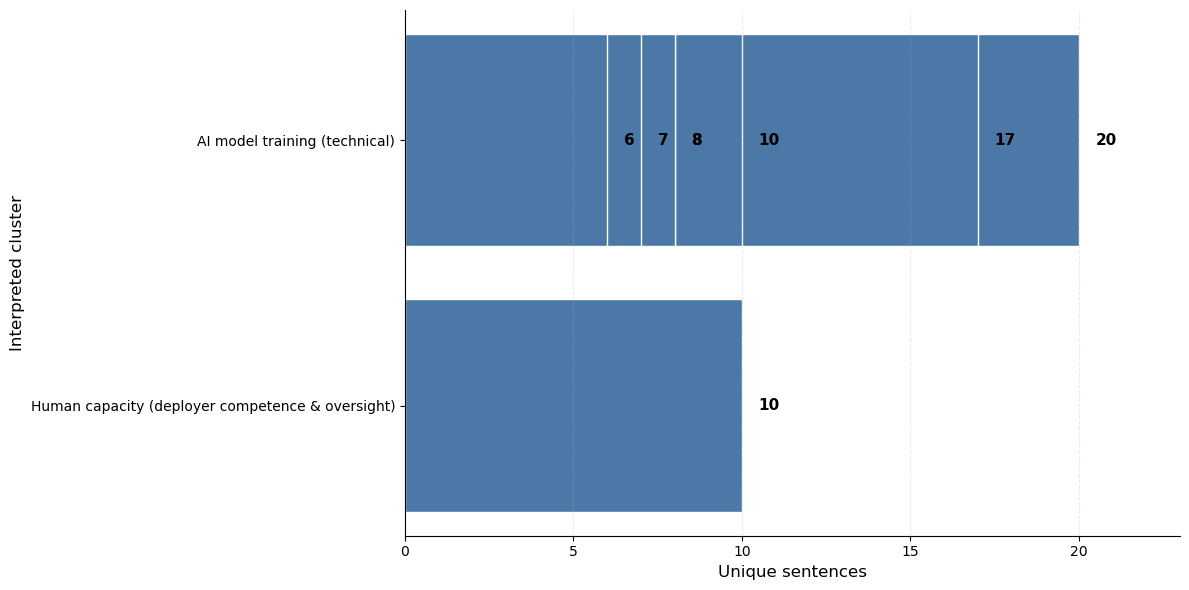

In [76]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    cluster_summary["cluster_label"],
    cluster_summary["n_sentences"],
    color="#4C78A8",
    edgecolor="white",
    linewidth=1
)

# Add value labels at the END of each bar
for i, (bar, val) in enumerate(zip(bars, cluster_summary["n_sentences"])):
    ax.text(
        bar.get_width() + 0.5,  # slightly to the right of bar end
        bar.get_y() + bar.get_height() / 2,  # centered vertically
        f'{val}',
        va='center',
        ha='left',
        fontsize=11,
        fontweight='bold'
    )

ax.set_xlabel("Unique sentences", fontsize=12)
ax.set_ylabel("Interpreted cluster", fontsize=12)
# ax.set_title("EU AI Act: Discovered semantic groups among 'training' sentences", 
#              fontsize=13, fontweight='bold', pad=15)

# Extend x-axis to make room for labels
max_val = cluster_summary["n_sentences"].max()
ax.set_xlim(0, max_val + 3)

ax.invert_yaxis()
ax.grid(axis="x", alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

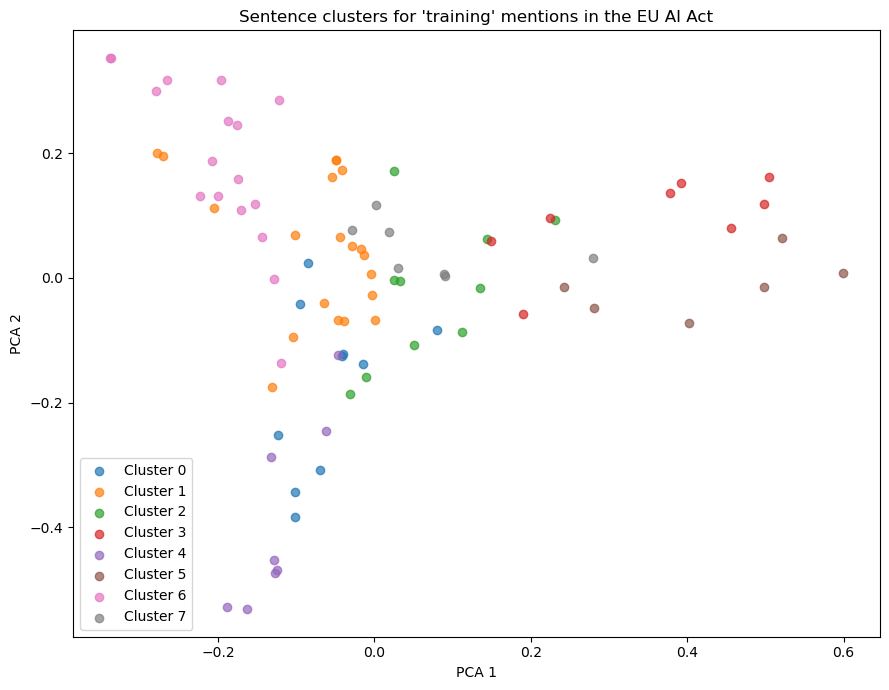

In [72]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray())

plot_df = df_unique_sent_2.copy()
plot_df["x"] = X_2d[:, 0]
plot_df["y"] = X_2d[:, 1]

plt.figure(figsize=(9, 7))
for cl in sorted(plot_df["cluster"].unique()):
    subset = plot_df[plot_df["cluster"] == cl]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {cl}", alpha=0.7)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Sentence clusters for 'training' mentions in the EU AI Act")
plt.legend()
plt.tight_layout()
plt.show()